<a href="https://colab.research.google.com/github/minjeon99/ESAA-10th-OB/blob/Week12/w12_fri_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **4. 합성곱 신경망(CNN)**

## **05 개/고양이 분류**
고성능 GPU 탑재 PC가 아닐 경우, 이미지 파일의 용량이 크거나 파일 개수가 많아서 컴퓨터 메모리/그래픽 카드 메모리가 부족한 상황 자주 발생

➡️ 이미지 데이터셋을 batch 단위로 나눈 뒤, 배치 1개를 읽어와 딥러닝 모델에 주입하여 메모리 부담 없이 학습
- iterator(반복 객체)를 통해 각 배치를 한 개씩 모델에 입력하여 훈련하기
- TensorFlow Keras의 `ImageDataGenerator` 함수

### **1. 분석 준비**

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import numpy as np
import matplotlib.pylab as plt

- 데이터: https://www.kaggle.com/datasets/tongpython/cat-and-dog?select=training_set

In [17]:
source_filename = "/content/dataset/cat-and-dog.zip"

# 저장할 경로
extract_folder = "/content/dataset/"   # 코랩 환경에 임시 저장

# 압축 해제
import shutil
shutil.unpack_archive(source_filename, extract_folder)

In [26]:
# 훈련 셋, 검증 셋 저장위치 지정
train_dir = extract_folder + "training_set/training_set"
valid_dir = extract_folder + "test_set/test_set"
print(train_dir)
print(valid_dir)

/content/dataset/training_set/training_set
/content/dataset/test_set/test_set


### **2. 모델 학습**

#### **ImageDataGenerator**

In [27]:
# 이미지 데이터 제너레이터 정의 (Augmentation 미적용)
image_gen = ImageDataGenerator(rescale=(1/255.)) # 0~1 정규화
image_gen

#### **flow_from_directory**
- image generator 객체에 `flow_from_directory` 함수 적용
  
  → 지정한 폴더에서 이미지를 가져와 반복 이터레이션이 가능하도록 데이터셋 처리

In [28]:
# flow_from_directory 함수로 폴더에서 이미지 가져와서 제너레이터 객체로 정리
train_gen = image_gen.flow_from_directory(train_dir,
                                          batch_size=32,
                                          target_size=(224, 224),
                                          classes=['cats','dogs'], # 실제 이미지가 들어있는 하위 폴더 이름인 'cats', 'dogs'
                                          class_mode = 'binary',
                                          seed=2020)

valid_gen = image_gen.flow_from_directory(valid_dir,
                                          batch_size=32,
                                          target_size=(224, 224),
                                          classes=['cats','dogs'],
                                          class_mode = 'binary',
                                          seed=2020)

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


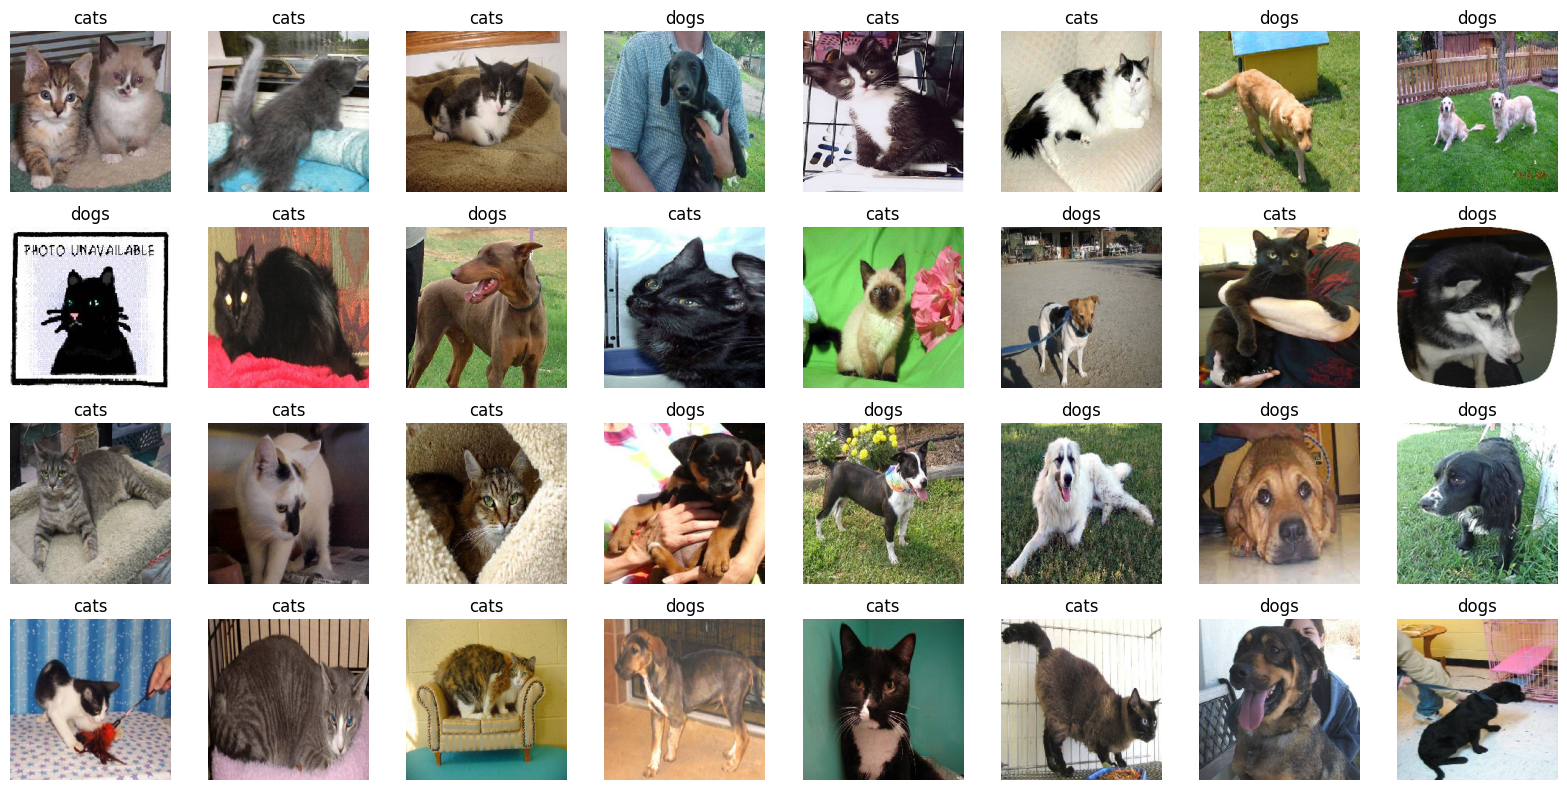

In [30]:
# 샘플 이미지 출력
class_labels = ['cats', 'dogs']
batch = next(train_gen)
images, labels = batch[0], batch[1]

plt.figure(figsize=(16, 8))
for i in range(32):

    ax = plt.subplot(4, 8, i + 1)
    plt.imshow(images[i])
    plt.title(class_labels[labels[i].astype(int)])
    plt.axis("off")
plt.tight_layout()
plt.show()

#### **모델 훈련**
- '배치 정규화 - 합성곱 - 풀링'으로 구성된 단위 블럭을 3개 반복
- 최종 분류기: Dense Layer
- 최종 출력 레이어: 노드 1개
  - 활성화 함수: sigmoid

In [31]:
# Sequential API를 사용하여 샘플 모델 생성

def build_model():

    model = tf.keras.Sequential([

        # Convolution 층
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Classifier 출력층
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])

    return model

model = build_model()

- optimizer, loss function 지정
- 모델 컴파일
- 20 epchos 훈련

In [34]:
# 모델 컴파일
model.compile(optimizer=tf.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 모델 훈련
history = model.fit(train_gen, validation_data=valid_gen, epochs=20)

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/backend/tensorflow/nn.py:707: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


251/251 ━━━━━━━━━━━━━━━━━━━━ 48s 137ms/step - accuracy: 0.5474 - loss: 7.5229 - val_accuracy: 0.6510 - val_loss: 0.6487
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 62s 94ms/step - accuracy: 0.6860 - loss: 0.6016 - val_accuracy: 0.6283 - val_loss: 0.6141
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - accuracy: 0.6800 - loss: 0.5848 - val_accuracy: 0.6673 - val_loss: 0.5874
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 25s 96ms/step - accuracy: 0.6997 - loss: 0.5789 - val_accuracy: 0.6723 - val_loss: 0.6053
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 40s 93ms/step - accuracy: 0.7274 - loss: 0.5430 - val_accuracy: 0.7405 - val_loss: 0.5505
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.7509 - loss: 0.5202 - val_accuracy: 0.7504 - val_loss: 0.5150
Epoch 7/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 40s 88ms/step - accuracy: 0.7714 - loss: 0.4775 - val_accuracy: 0.7257 - val_loss: 0.5510
Epoch 8/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - accuracy: 0.7719 - loss: 0.4824 - val_accura

- train accuracy: 92%
- validation accuracy: 77%

  ➡️ Overfitting

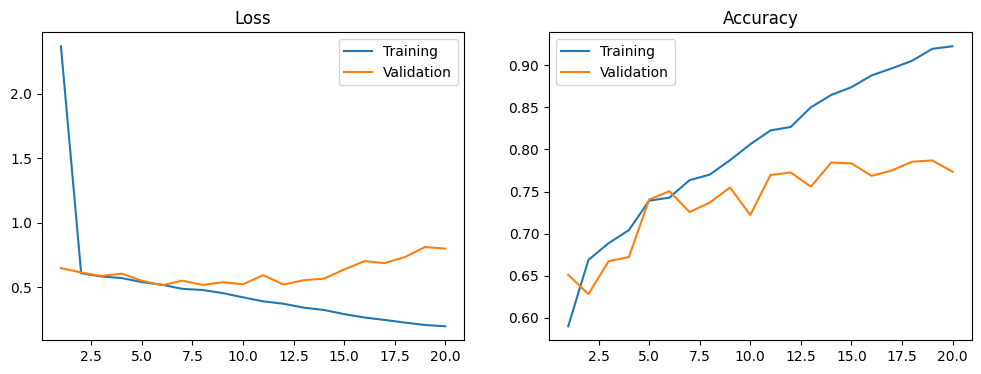

In [35]:
# 손실함수, 정확도 그래프 그리기
def plot_loss_acc(history, epoch):

    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc, val_acc = history.history['accuracy'], history.history['val_accuracy']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(range(1, epoch + 1), loss, label='Training')
    axes[0].plot(range(1, epoch + 1), val_loss, label='Validation')
    axes[0].legend(loc='best')
    axes[0].set_title('Loss')

    axes[1].plot(range(1, epoch + 1), acc, label='Training')
    axes[1].plot(range(1, epoch + 1), val_acc, label='Validation')
    axes[1].legend(loc='best')
    axes[1].set_title('Accuracy')

    plt.show()

plot_loss_acc(history, 20)

- 손실함수 그래프를 보면 과대적합이 빠르게 발생함 ⚠️

#### **데이터 증강**
- `ImageDataGenerator`를 사용하면 다양한 데이터 증강 기법을 클래스 함수의 매개변수 속성으로 편리하게 지정
  - `horizontal_flip`: 좌우방향 뒤집기
  - `ratation_range`: 최대 회전 각도 지정
  - `shear_range`: 반시계 방향으로 밀리도록 변형

    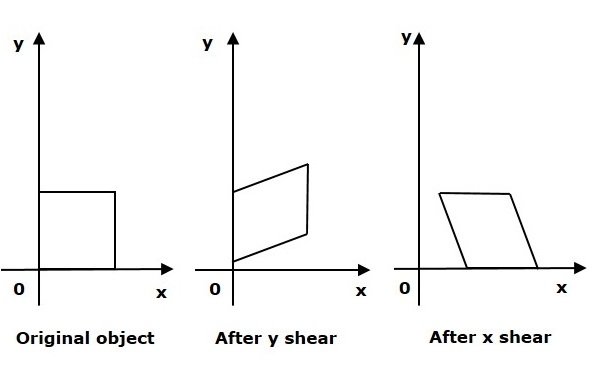
  - `zoom_range`: 줌으로 확대
- 이미지를 배치 크기 단위로 불러와 데이터 증강 기법 적용 → 목표 크기에 맞춰서 미니 배치 구성 ⇒ 반복 이터레이션 객체 생성
- 모델 인스턴스: epoch 40으로 증가

In [38]:
# 이미지 데이터 제너레이터 정의 (Augmentation 적용)
image_gen_aug = ImageDataGenerator(rescale=1/255.,
                                   horizontal_flip=True,
                                   rotation_range=30,
                                   shear_range=0.15,
                                   zoom_range=0.3)

# flow_from_directory 함수로 폴더에서 이미지 가져와서 제너레이터 객체로 정리
train_gen_aug = image_gen_aug.flow_from_directory(train_dir,
                                                  batch_size=32,
                                                  target_size=(224,224),
                                                  classes=['cats','dogs'],
                                                  class_mode = 'binary',
                                                  seed=2020)

valid_gen_aug = image_gen_aug.flow_from_directory(valid_dir,
                                                  batch_size=32,
                                                  target_size=(224,224),
                                                  classes=['cats','dogs'],
                                                  class_mode = 'binary',
                                                  seed=2020)

# 모델 생성
model_aug = build_model()

# 모델 컴파일
model_aug.compile(optimizer=tf.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 모델 훈련
history_aug = model_aug.fit(train_gen_aug, validation_data=valid_gen_aug, epochs=40)

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.
Epoch 1/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 130s 484ms/step - accuracy: 0.5570 - loss: 9.0461 - val_accuracy: 0.5606 - val_loss: 0.6834
Epoch 2/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 137s 476ms/step - accuracy: 0.6376 - loss: 0.6299 - val_accuracy: 0.6565 - val_loss: 0.6105
Epoch 3/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 124s 485ms/step - accuracy: 0.6593 - loss: 0.6078 - val_accuracy: 0.6742 - val_loss: 0.5926
Epoch 4/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 141s 479ms/step - accuracy: 0.6768 - loss: 0.5953 - val_accuracy: 0.6906 - val_loss: 0.5840
Epoch 5/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 162s 558ms/step - accuracy: 0.6714 - loss: 0.5940 - val_accuracy: 0.6995 - val_loss: 0.5522
Epoch 6/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 182s 484ms/step - accuracy: 0.6879 - loss: 0.5805 - val_accuracy: 0.6817 - val_loss: 0.5969
Epoch 7/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 141s 481ms/step - accuracy: 0.6900 - loss: 0.5675 - val_accuracy: 0.6950 - val_loss:

- 40 epoch까지 과대적합이 발생하지 않고 약 86%의 정확도
  
  ➡️ epoch를 더 늘리면 모델 성능이 개선될 여지


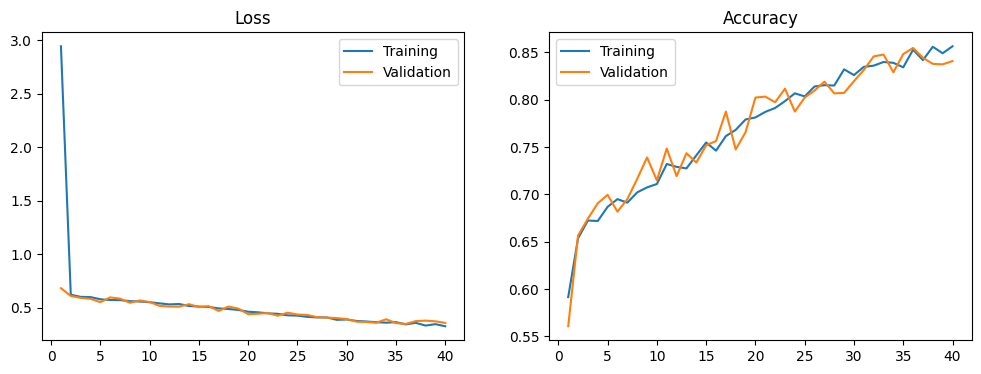

In [39]:
# 손실함수, 정확도 그래프 그리기
plot_loss_acc(history_aug, 40)

- 과대적합/과소적합 발생하지 않고 학습이 잘 진행됨

## **06 객체 탐지(Object Detection)**
- Object Detection(객체 탐지, 객체 검출)
  - 대표적인 응용 분야: 자율주행차
    - 카메라/센서를 활용하여 도로 상황 파악
    - 도로를 이동하는 다른 자동차의 움직임, 거리를 횡단하는 사람들, 장애물 등 식별
  - 입력 이미지로부터 1️⃣ 여러 객체 찾기, 2️⃣ 각 객체가 무엇을 나타내는지 분류하기
    1. 객체 찾기(객체를 둘러싸는 box 그리기): 경계의 좌표 값 → 회귀
    2. 객체 구분 → 분류

### **1. 텐서플로 허브 활용**

In [40]:
import tensorflow as tf  # tensorflow
import tensorflow_hub as tfhub  # tensorflow hub

- **텐서플로 허브(Tensorflow Hub)**: 이미지 분류, 객체 탐지, 스타일 전이, 텍스트 분류 등 다양한 딥러닝 문제를 해결할 수 있는 검증된 사전 학습(pre-trained) 모델 제공하는 저장소(repository)

#### **샘플 이미지 준비**

337276/337276 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


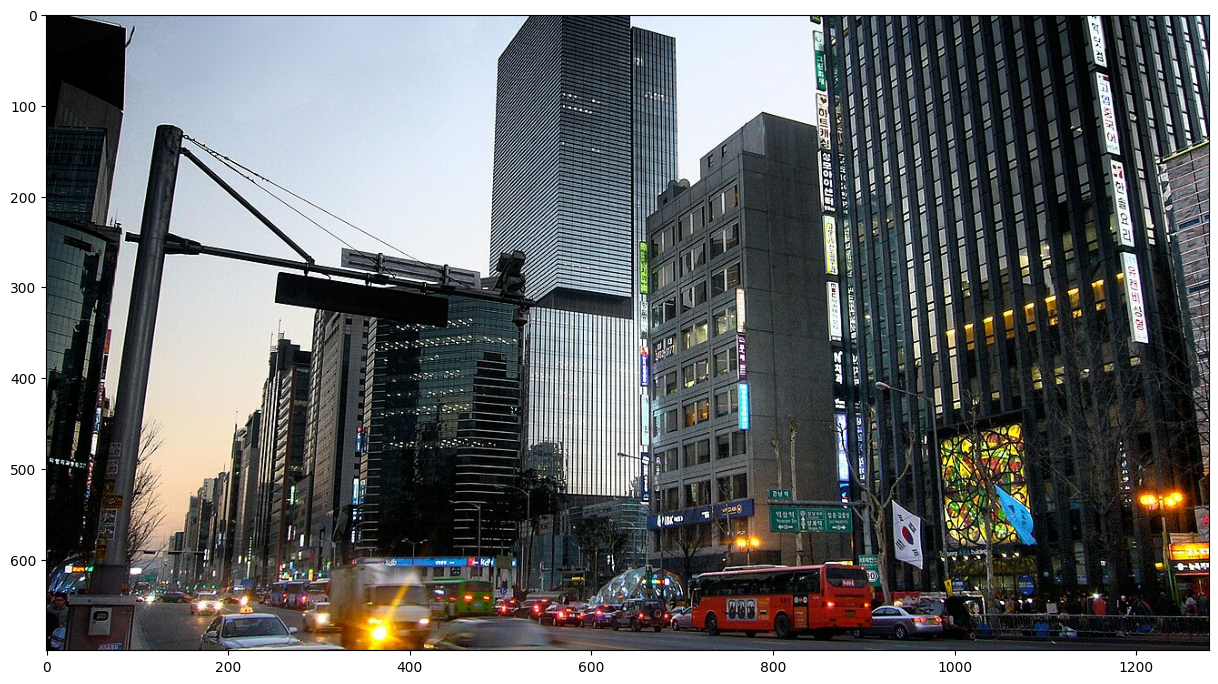

In [41]:
# 샘플 이미지 다운로드
img_path = 'https://upload.wikimedia.org/wikipedia/commons/thumb/c/c4/Gangnam_Seoul_January_2009.jpg/1280px-Gangnam_Seoul_January_2009.jpg'
img = tf.keras.utils.get_file(fname='gangnam', origin=img_path)
img = tf.io.read_file(img)   # 파일 객체를 string으로 변환
img = tf.image.decode_jpeg(img, channels=3)   # 문자(string)를 숫자(unit8) 텐서로 변환
img = tf.image.convert_image_dtype(img, tf.float32)   # 0 ~ 1 범위로 정규화

import matplotlib.pylab as plt
plt.figure(figsize=(15, 10))
plt.imshow(img)

- 사전 학습 모델은 배치 크기를 포함하여 4차원 텐서를 입력으로 받음

  ➡️ 가장 앞쪽으로 axis 0에 새로운 축 추가

In [42]:
img_input = tf.expand_dims(img, 0)  # batch_size 추가
img_input.shape

TensorShape([1, 700, 1280, 3])

#### **사전 학습 모델**

In [44]:
# TensorFlow Hub에서 모델 가져오기 - FasterRCNN+InceptionResNet V2
model = tfhub.load("https://tfhub.dev/google/faster_rcnn/openimages_v4/inception_resnet_v2/1")

In [45]:
# 모델 시그니처(용도) 확인
model.signatures.keys()

KeysView(_SignatureMap({'default': <ConcreteFunction () -> Dict[['detection_scores', TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)], ['detection_class_names', TensorSpec(shape=(None, 1), dtype=tf.string, name=None)], ['detection_class_entities', TensorSpec(shape=(None, 1), dtype=tf.string, name=None)], ['detection_boxes', TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)], ['detection_class_labels', TensorSpec(shape=(None, 1), dtype=tf.int64, name=None)]] at 0x7CBC33C0EE00>}))

In [46]:
# 객체탐지 모델 생성
obj_detector = model.signatures['default']
obj_detector

<ConcreteFunction () -> Dict[['detection_scores', TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)], ['detection_class_names', TensorSpec(shape=(None, 1), dtype=tf.string, name=None)], ['detection_class_entities', TensorSpec(shape=(None, 1), dtype=tf.string, name=None)], ['detection_boxes', TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)], ['detection_class_labels', TensorSpec(shape=(None, 1), dtype=tf.int64, name=None)]] at 0x7CBC33C0EE00>

#### **추론**

In [47]:
# 모델을 이용하여 예측 (추론)
result = obj_detector(img_input)
result.keys()

dict_keys(['detection_scores', 'detection_class_names', 'detection_class_entities', 'detection_boxes', 'detection_class_labels'])

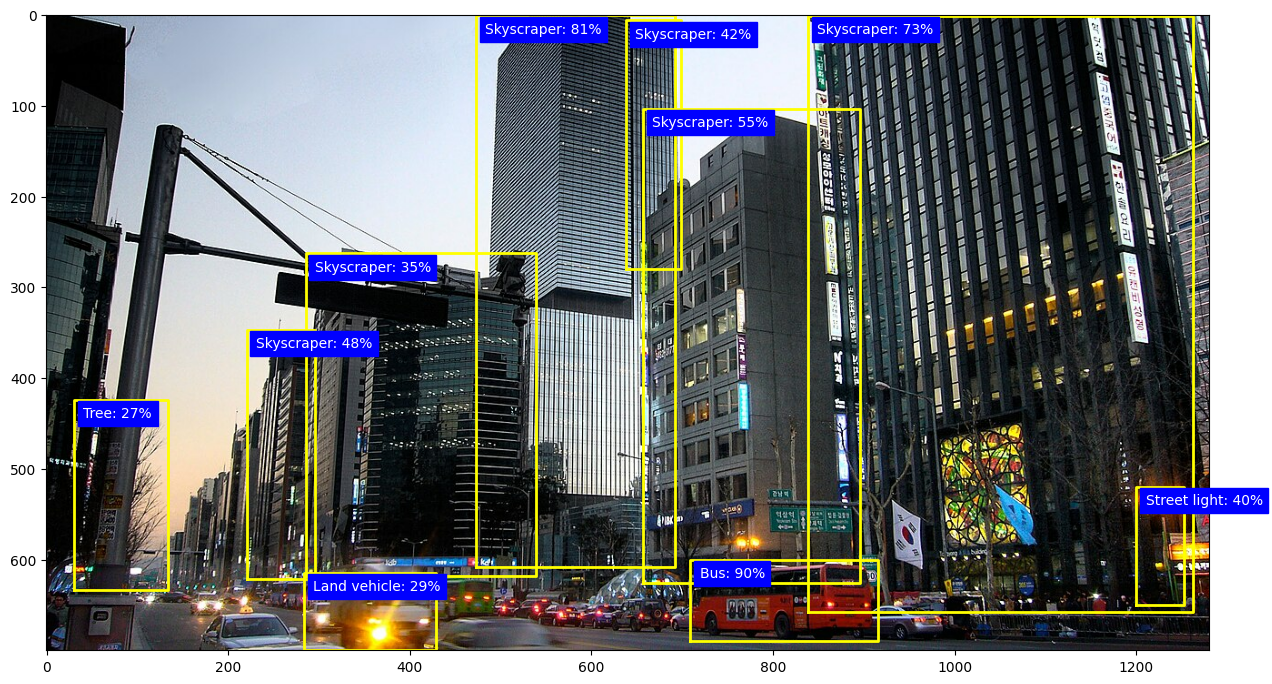

In [48]:
# 탐지한 객체의 개수
len(result["detection_scores"])# 객체 탐지 결과를 시각화
boxes = result["detection_boxes"]    # Bounding Box 좌표 예측값
labels = result["detection_class_entities"]   # 클래스 값
scores = result["detection_scores"]   # 신뢰도 (confidence)

# 샘플 이미지 가로 세로 크기
img_height, img_width = img.shape[0], img.shape[1]

# 탐지할 최대 객체의 수
obj_to_detect = 10

# 시각화
plt.figure(figsize=(15, 10))
for i in range(min(obj_to_detect, boxes.shape[0])):
    if scores[i] >= 0.2:
        (ymax, xmin, ymin, xmax) = (boxes[i][0]*img_height, boxes[i][1]*img_width,
                                    boxes[i][2]*img_height, boxes[i][3]*img_width)

        plt.imshow(img)
        plt.plot([xmin, xmax, xmax, xmin, xmin], [ymin, ymin, ymax, ymax, ymin],
                 color='yellow', linewidth=2)

        class_name = labels[i].numpy().decode('utf-8')
        infer_score = int(scores[i].numpy()*100)
        annotation = "{}: {}%".format(class_name, infer_score)
        plt.text(xmin+10, ymax+20, annotation,
                 color='white', backgroundcolor='blue', fontsize=10)

### **2. YOLO 객체 탐지**
- **YOLO(You Only Look Once)**: 경계 박스와 예측 클래스를 하나의 회귀 문제로 접근

  = 하나의 신경망이 한 번만 계산해 두 가지 일을 한꺼번에 처리 ➡️ 매우 빠른 속도

  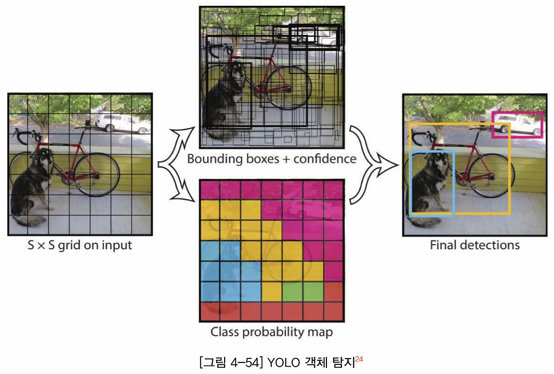

#### **Darknet YOLO 모델 추론하기**

In [49]:
# 깃헙 저장소 복제
!git clone https://github.com/AlexeyAB/darknet

Cloning into 'darknet'...
remote: Enumerating objects: 15873, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 15873 (delta 4), reused 12 (delta 0), pack-reused 15851 (from 1)
Receiving objects: 100% (15873/15873), 14.46 MiB | 9.92 MiB/s, done.
Resolving deltas: 100% (10687/10687), done.


In [50]:
# GPU 활성화
%cd darknet
!sed -i 's/GPU=0/GPU=1/' Makefile
!sed -i 's/CUDNN=0/CUDNN=1/' Makefile
!sed -i 's/CUDNN_HALF=0/CUDNN_HALF=1/' Makefile

# Darknet 생성
!make

/content/darknet
mkdir -p ./obj/
mkdir -p backup
mkdir -p results
chmod +x *.sh
g++ -std=c++11 -std=c++11 -Iinclude/ -I3rdparty/stb/include -DGPU -I/usr/local/cuda/include/ -DCUDNN -DCUDNN_HALF -Wall -Wfatal-errors -Wno-unused-result -Wno-unknown-pragmas -fPIC -rdynamic -Ofast -DGPU -DCUDNN -I/usr/local/cudnn/include -DCUDNN_HALF -c ./src/image_opencv.cpp -o obj/image_opencv.o
g++ -std=c++11 -std=c++11 -Iinclude/ -I3rdparty/stb/include -DGPU -I/usr/local/cuda/include/ -DCUDNN -DCUDNN_HALF -Wall -Wfatal-errors -Wno-unused-result -Wno-unknown-pragmas -fPIC -rdynamic -Ofast -DGPU -DCUDNN -I/usr/local/cudnn/include -DCUDNN_HALF -c ./src/http_stream.cpp -o obj/http_stream.o
./src/http_stream.cpp: In member function ‘bool JSON_sender::write(const char*)’:
./src/http_stream.cpp:253:21: warning: unused variable ‘n’ []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wunused-variable-Wunused-variable]8;;]
  253 |                 int n = _write(client, outputbuf, outlen);
    

In [59]:
!wget https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v3_optimal/yolov4.weights -batch 2

Continuing in background, pid 40489.


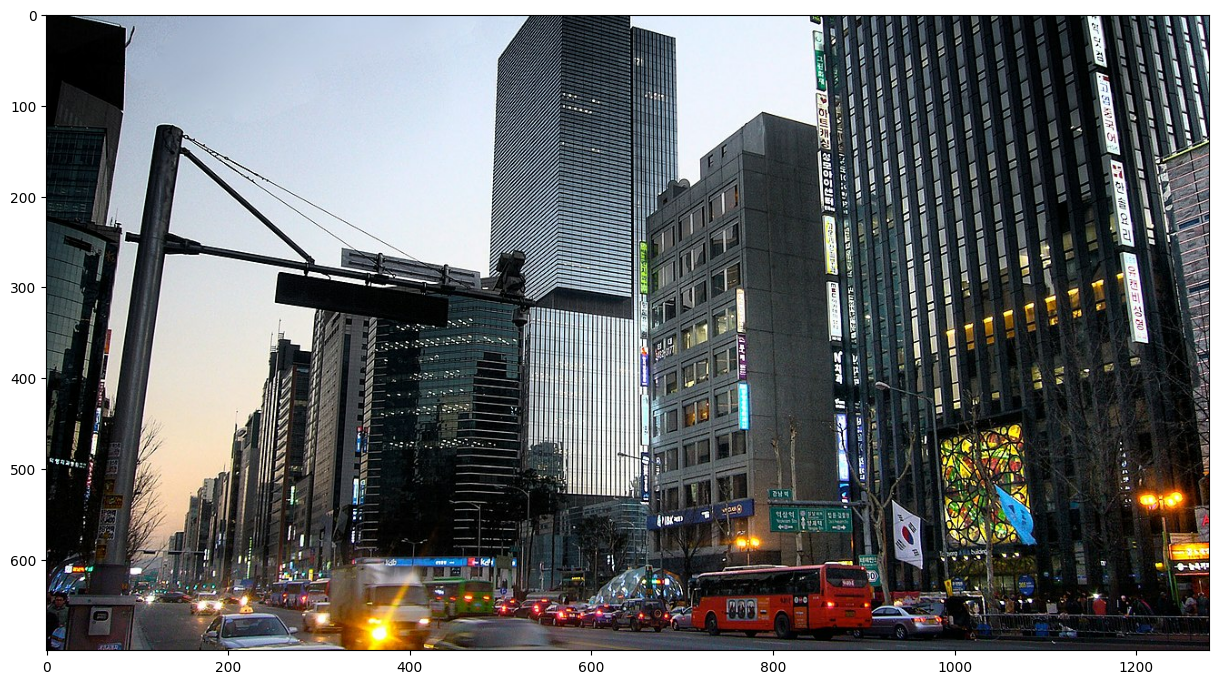

In [53]:
import matplotlib.pylab as plt
import tensorflow as tf
plt.figure(figsize=(15, 10))
img = tf.io.read_file('/content/gangnam.jpg')
img = tf.image.decode_jpeg(img, channels=3)
img = tf.image.convert_image_dtype(img, tf.float32)
plt.imshow(img)

In [60]:
# Darknet 실행
!./darknet detector test cfg/coco.data cfg/yolov4.cfg yolov4.weights /content/gangnam.jpg

 CUDA-version: 12020 (12020), cuDNN: 8.9.6, CUDNN_HALF=1, GPU count: 1  
 CUDNN_HALF=1 
 OpenCV isn't used - data augmentation will be slow 
 0 : compute_capability = 750, cudnn_half = 1, GPU: Tesla T4 
net.optimized_memory = 0 
mini_batch = 1, batch = 8, time_steps = 1, train = 0 
   layer   filters  size/strd(dil)      input                output
   0 Create CUDA-stream - 0 
 Create cudnn-handle 0 
conv     32       3 x 3/ 1    608 x 608 x   3 ->  608 x 608 x  32 0.639 BF
   1 conv     64       3 x 3/ 2    608 x 608 x  32 ->  304 x 304 x  64 3.407 BF
   2 conv     64       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  64 0.757 BF
   3 route  1 		                           ->  304 x 304 x  64 
   4 conv     64       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  64 0.757 BF
   5 conv     32       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  32 0.379 BF
   6 conv     64       3 x 3/ 1    304 x 304 x  32 ->  304 x 304 x  64 3.407 BF
   7 Shortcut Layer: 4,  wt = 0, wn = 0, outputs: 304 x 3

- `CUDA Error: out of memory`로 *predictions.jpg* 파일이 만들어지지 않은 것 같음
- batch size도 2까지 줄여봤으나 실행 안 됨

In [61]:
plt.figure(figsize=(15, 10))
img = tf.io.read_file('/content/darknet/predictions.jpg')
img = tf.image.decode_jpeg(img, channels=3)
img = tf.image.convert_image_dtype(img, tf.float32)
plt.imshow(img)

NotFoundError: {{function_node __wrapped__ReadFile_device_/job:localhost/replica:0/task:0/device:CPU:0}} /content/darknet/predictions.jpg; No such file or directory [Op:ReadFile]

<Figure size 1500x1000 with 0 Axes>

#### **나만의 YOLO 모델 생성**

In [62]:
# 필요한 패키지를 임포트 함
import tensorflow as tf
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

# 파라미터 설정

# 이미지 크기
width_size = 256
hight_size = 256
channel_size = 3
img_size = (width_size,hight_size,channel_size)

# 이미지를 나눌 크기
cell_num = 3
# 찾고자 하는 객체 개수
class_num = 3
# 한셀에 그릴 박스 수
anchor_num = 1
label_num = anchor_num * (5 + class_num)
# 학습 수
epoch_num = 20000
# 로스 비중
loss_p_rate = 1.0
loss_cod_rate = 5.0
loss_c_rate = 1.0
loss_p_no_rate = 0.5

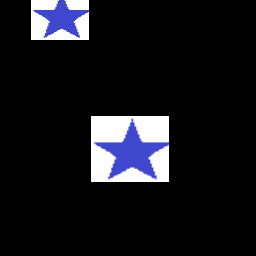

In [63]:
# 랜덤하게 도형을 그리고, 실제 정답 값을 생성하는 함수 정의
# 0.png / 1.png / 2.png 파일이 필요함

def make_img_label():
    img = np.zeros((hight_size+400,width_size+400,channel_size))
    label = np.zeros((cell_num,cell_num,label_num))
    num_shape = np.random.randint(1,4)
    i = np.random.choice(range(cell_num),num_shape,replace=False)
    j = np.random.choice(range(cell_num),num_shape,replace=False)

    img_0 = cv2.imread('/content/0.png')
    img_1 = cv2.imread('/content/1.png')
    img_2 = cv2.imread('/content/2.png')

    for n_h in range(num_shape):
        row = i[n_h]
        col = j[n_h]

        shape_type = np.random.randint(0,class_num)
        x_rate = np.random.rand()
        y_rate = np.random.rand()
        w_rate = np.random.rand() * 0.3 +0.1
        h_rate = np.random.rand() * 0.3 +0.1

        label[row,col]=[1,x_rate,y_rate,w_rate,h_rate,0,0,0]
        label[row,col,5+shape_type]=1

        x = int(x_rate * width_size/cell_num + col * width_size/cell_num)
        y = int(y_rate * hight_size/cell_num + row * hight_size/cell_num)
        w = int(w_rate * width_size/2) * 2
        h = int(h_rate * hight_size/2) * 2

        if(shape_type==0):
            input_img = cv2.resize(img_0,(w,h))
        if(shape_type==1):
            input_img = cv2.resize(img_1,(w,h))
        if(shape_type==2):
            input_img = cv2.resize(img_2,(w,h))

        img[y-int(h/2)+200 : y+int(h/2)+200, x-int(w/2)+200 : x+int(w/2)+200] =input_img
    img = img[200:200+hight_size,200:200+width_size]

    return img,label

img,label = make_img_label()
cv2_imshow(img)

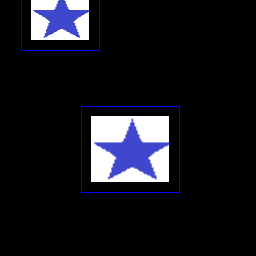

In [64]:
# 이미지와 정답(혹은 예측값)을 넣으면 박스를 그려주는 함수 정의
# 임계값 th 설정 (객체가 있다는 확률이 th이상일 때만 박스 생성)
def show_box(img,label,th=0.3):
    b_img = np.zeros((hight_size+400,width_size+400,3))
    b_img[200:200+hight_size,200:200+width_size] = img
    for i in range(cell_num):
        for j in range(cell_num):
            if(label[i,j,0] > th):
                x_rate = label[i,j,1]
                y_rate = label[i,j,2]
                w_rate = label[i,j,3]
                h_rate = label[i,j,4]
                shape_type=np.argmax(label[i,j,5:])
                if(shape_type==0):
                    line_color = [0,0,255]
                if(shape_type==1):
                    line_color = [255,0,0]
                if(shape_type==2):
                    line_color = [0,255,0]
                x = int(x_rate * width_size/3 + j * width_size/3)
                y = int(y_rate * hight_size/3 + i * hight_size/3)
                w = int(w_rate * width_size/2) * 2 + 20
                h = int(h_rate * hight_size/2) * 2 + 20

                cv2.rectangle(b_img,(x-int(w/2)+200,y-int(h/2)+200),(x+int(w/2)+200,y+int(h/2)+200),line_color)

    b_img = b_img[200:200+hight_size,200:200+width_size]

    return b_img

cv2_imshow(show_box(img,label))

In [65]:
# VGG16모델을 베이스로 마지막 부분만 수정하는 모델 생성 (전이 학습)
vgg_model = tf.keras.applications.VGG16(include_top=False,input_shape=img_size)
vgg_model.trainable=False

i=tf.keras.Input(shape=img_size)
out=tf.keras.layers.Lambda((lambda x : x/255.))(i)
out = vgg_model(out)
out = tf.keras.layers.Conv2D(256,3,padding='same')(out)
out = tf.keras.layers.Conv2D(128,3,padding='same')(out)
out = tf.keras.layers.Conv2D(64,3,padding='same')(out)
out = tf.keras.layers.Flatten()(out)
out = tf.keras.layers.Dense(1024,activation='relu')(out)
out = tf.keras.layers.Dense(3*3*8,activation='sigmoid')(out)
out = tf.keras.layers.Reshape((3,3,8))(out)

yolo_model = tf.keras.Model(inputs=[i],outputs=[out])
opt = tf.keras.optimizers.Adam(0.00001)

# 모델 요약
yolo_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda (Lambda)                      │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 8, 8, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 8, 8, 256)           │       1,179,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 8, 8, 128)           │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 8, 8, 64)            │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1024)                │       4,195,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 72)                  │          73,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 3, 3, 8)             │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,532,552 (78.33 MB)

 Trainable params: 5,817,864 (22.19 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [66]:
# 학습과정을 동영상으로 기록
fcc=cv2.VideoWriter_fourcc(*'DIVX')
out=cv2.VideoWriter('hjk_yolo.avi',fcc,1.0,(width_size,hight_size))


for e in range(epoch_num):
    img,label = make_img_label()
    img = np.reshape(img,(1,hight_size,width_size,3))
    label = np.reshape(label,(1,3,3,8))
    loss_p_list=[]
    loss_cod_list = []
    loss_c_list = []
    loss_p_no_list = []
    with tf.GradientTape() as tape:
        pred = yolo_model(img)
        # 이미지를 구분한 셀을 탐험
        for i in range(3):
            for j in range(3):
                # 해당 셀에 객체가 있을 경우는 확률, 박스 크기, 클래스까지 모두 Loss로 계산
                if(label[0,i,j,0]==1):
                    loss_p_list.append(tf.square(label[0,i,j,0]-pred[0,i,j,0]))
                    loss_cod_list.append(tf.square(label[0,i,j,1]-pred[0,i,j,1]))
                    loss_cod_list.append(tf.square(label[0,i,j,2]-pred[0,i,j,2]))
                    loss_cod_list.append(tf.square(label[0,i,j,3]-pred[0,i,j,3]))
                    loss_cod_list.append(tf.square(label[0,i,j,4]-pred[0,i,j,4]))
                    loss_c_list.append(tf.square(label[0,i,j,5]-pred[0,i,j,5]))
                    loss_c_list.append(tf.square(label[0,i,j,6]-pred[0,i,j,6]))
                    loss_c_list.append(tf.square(label[0,i,j,7]-pred[0,i,j,7]))
                # 해당 셀에 객체가 없을 경우 객체가 없을 확률만 Loss로 계산
                else:
                    loss_p_no_list.append(tf.square(label[0,i,j,0]-pred[0,i,j,0]))
        loss_p=tf.reduce_mean(loss_p_list)
        loss_cod =tf.reduce_mean(loss_cod_list)
        loss_c = tf.reduce_mean(loss_c_list)
        loss_p_no = tf.reduce_mean(loss_p_no_list)
        # 각 Loss를 비중을 곱해 더해 최종 Loss를 계산
        loss = loss_p_rate * loss_p + loss_cod_rate * loss_cod + loss_c_rate * loss_c + loss_p_no_rate * loss_p_no
    # Loss에 대한 Grad를 구하고, 각 파라미터를 업데이트
    vars = yolo_model.trainable_variables
    grad = tape.gradient(loss, vars)
    opt.apply_gradients(zip(grad, vars))
    # 100번 마다 동영상에 이미지를 기록한다
    if(e%100==0):
        img = np.reshape(img,(256,256,3))
        label = pred.numpy()
        label = np.reshape(label,(3,3,8))
        sample_img = np.uint8(show_box(img,label))
        out.write(sample_img)
    print(e,"완료",loss.numpy())
out.release()

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
15000 완료 0.18661723
15001 완료 0.05862458
15002 완료 0.0501127
15003 완료 0.06869923
15004 완료 0.019003231
15005 완료 0.02034243
15006 완료 0.04034987
15007 완료 0.026335686
15008 완료 0.07073589
15009 완료 0.02888297
15010 완료 0.014335028
15011 완료 0.0118173715
15012 완료 0.05595345
15013 완료 0.07413386
15014 완료 0.013161921
15015 완료 0.13773409
15016 완료 0.03377609
15017 완료 0.048481934
15018 완료 0.028278917
15019 완료 0.10484205
15020 완료 0.022043183
15021 완료 0.0107792765
15022 완료 0.013159042
15023 완료 0.019140584
15024 완료 0.035583794
15025 완료 0.06956042
15026 완료 0.006518885
15027 완료 0.049762636
15028 완료 0.015574355
15029 완료 0.039634403
15030 완료 0.019524395
15031 완료 0.05265174
15032 완료 0.059296973
15033 완료 0.028505009
15034 완료 0.033343222
15035 완료 0.040565334
15036 완료 0.039484754
15037 완료 0.025480997
15038 완료 0.039050445
15039 완료 0.03230834
15040 완료 0.041234437
15041 완료 0.013663941
15042 완료 0.04616598
15043 완료 0.0286341
15044 완료 0.029548151
15045 완료 0.03892701
15046 완료 0.017354